## LIBRERIAS IMPORTADAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import plotly.graph_objects as go

## OBTENCIÓN DEL DATASET 

In [2]:
estadisticas= pd.read_csv("csv2/PlayerStatistics.csv",encoding="latin1",on_bad_lines="skip")

C:\Users\Administrador\AppData\Local\Temp\ipykernel_11092\3253645148.py:1: DtypeWarning: Columns (10,11,12,15,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  estadisticas= pd.read_csv("csv2/PlayerStatistics.csv",encoding="latin1",on_bad_lines="skip")


In [3]:
stats_temporada= estadisticas[["firstName","lastName","personId","gameId","playerteamName","opponentteamName","win","numMinutes","points","assists","blocks","steals","turnovers","foulsPersonal","fieldGoalsMade","fieldGoalsAttempted","fieldGoalsPercentage","threePointersMade","threePointersAttempted","threePointersPercentage","freeThrowsMade","freeThrowsAttempted","freeThrowsPercentage","reboundsOffensive","reboundsDefensive","reboundsTotal","plusMinusPoints","gameDate"]]

In [4]:
def parse_minutos(valor):
    if pd.isna(valor):
        return 0.0
    
    valor = str(valor).strip()
    
    if valor == "" or valor.lower() == "nan":
        return 0.0
    if ":" in valor:
        try:
            mins, segs = valor.split(":")
            return int(mins) + int(segs) / 60
        except (ValueError, ZeroDivisionError):
            return 0.0
    try:
        return float(valor)
    except ValueError:
        return 0.0

stats_temporada["numMinutes"] = stats_temporada["numMinutes"].apply(parse_minutos)

C:\Users\Administrador\AppData\Local\Temp\ipykernel_11092\1333726176.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stats_temporada["numMinutes"] = stats_temporada["numMinutes"].apply(parse_minutos)


In [5]:
NOT_REAL_TEAMS = {
    'Durant', 'East', 'Giannis', 'Global Stars', 'Jerusalem B.C.', 'LeBron',
    'Loong-Lions', 'OGs', 'Phoenix', 'Rising Stars', 'Stars', 'Stephen', 'Stripes',
    'Team Austin', 'Team Melo', 'Team T-Mac', 'Team Vince', 'United',
    'West', 'World', 'Young Stars','Phoenix'
}

In [6]:
stats_temporada=stats_temporada[~stats_temporada['playerteamName'].isin(NOT_REAL_TEAMS)]
stats_temporada=stats_temporada[~stats_temporada['opponentteamName'].isin(NOT_REAL_TEAMS)]

In [7]:
stats_temporada["gameDate"] = pd.to_datetime(stats_temporada["gameDate"])

def calcular_temporada(fecha):
    if fecha.month >= 9:
        return fecha.year
    else:
        return fecha.year - 1

stats_temporada["season"] = stats_temporada["gameDate"].apply(calcular_temporada)


# PROMEDIOS
cols_mean = [
    "numMinutes", "points", "assists", "blocks", "steals", "turnovers",
    "foulsPersonal",
    "reboundsOffensive", "reboundsDefensive", "reboundsTotal",
    "plusMinusPoints"
]


# TOTALES
cols_sum = [
    "fieldGoalsMade", "fieldGoalsAttempted",
    "threePointersMade", "threePointersAttempted",
    "freeThrowsMade", "freeThrowsAttempted"
]


jugados = stats_temporada[
    stats_temporada["numMinutes"] > 0
]


agg_dict = {col: "mean" for col in cols_mean}
agg_dict.update({col: "sum" for col in cols_sum})

agg_dict["gameId"] = "count"
agg_dict["playerteamName"] = lambda x: sorted(x.unique())


df_temporada = (
    jugados
    .groupby(
        ["personId", "firstName", "lastName", "season"],
        as_index=False
    )
    .agg(agg_dict)
    .rename(columns={
        "gameId": "gamesPlayed",
        "playerteamName": "teams"
    })
)


# VICTORIAS
df_wins = (
    stats_temporada
    .groupby(["personId", "season"], as_index=False)
    .agg(wins=("win", "sum"))
)


df_temporada = df_temporada.merge(
    df_wins,
    on=["personId", "season"],
    how="left"
)

df_temporada["fieldGoalsPercentage"] = (
    df_temporada["fieldGoalsMade"] /
    df_temporada["fieldGoalsAttempted"]
)

df_temporada["threePointersPercentage"] = (
    df_temporada["threePointersMade"] /
    df_temporada["threePointersAttempted"]
)

df_temporada["freeThrowsPercentage"] = (
    df_temporada["freeThrowsMade"] /
    df_temporada["freeThrowsAttempted"]
)

df_temporada["twoPointersMade"] = (
    df_temporada["fieldGoalsMade"] -
    df_temporada["threePointersMade"]
)

df_temporada["twoPointersAttempted"] = (
    df_temporada["fieldGoalsAttempted"] -
    df_temporada["threePointersAttempted"]
)

df_temporada["twoPointersPercentage"] = (
    df_temporada["fieldGoalsMade"] -
    df_temporada["threePointersMade"]
) / df_temporada["twoPointersAttempted"]


df_temporada["fullName"] = (
    df_temporada["firstName"] + " " + df_temporada["lastName"]
)

df_temporada["numTeams"] = df_temporada["teams"].apply(len)

df_temporada.head()

,personId,firstName,lastName,season,numMinutes,points,assists,blocks,steals,turnovers,...,teams,wins,fieldGoalsPercentage,threePointersPercentage,freeThrowsPercentage,twoPointersMade,twoPointersAttempted,twoPointersPercentage,fullName,numTeams
0,2.0,Byron,Scott,1983.0,21.712766,10.202128,2.234043,0.223404,1.053191,1.510638,...,[Lakers],63.0,0.479436,0.227273,0.764368,398.0,807.0,0.493185,Byron Scott,1
1,2.0,Byron,Scott,1984.0,28.900000,16.160000,2.930000,0.210000,1.390000,1.590000,...,[Lakers],76.0,0.534646,0.444444,0.816176,643.0,1189.0,0.540791,Byron Scott,1
2,2.0,Byron,Scott,1985.0,29.488889,15.533333,2.288889,0.188889,1.155556,1.555556,...,[Lakers],65.0,0.510256,0.358974,0.807339,569.0,1092.0,0.521062,Byron Scott,1
3,2.0,Byron,Scott,1986.0,33.370000,16.630000,3.410000,0.220000,1.440000,1.690000,...,[Lakers],80.0,0.488839,0.393443,0.871069,585.0,1161.0,0.503876,Byron Scott,1
4,2.0,Byron,Scott,1987.0,37.571429,21.180952,3.752381,0.304762,1.800000,1.980952,...,[Lakers],77.0,0.520821,0.367521,0.859857,802.0,1471.0,0.545207,Byron Scott,1


In [8]:
df_players = pd.read_csv("csv2/Players.csv")

In [9]:
def construir_posicion(row):
    posiciones = []
    if row["guard"] == 1:
        posiciones.append("Guard")
    if row["forward"] == 1:
        posiciones.append("Forward")
    if row["center"] == 1:
        posiciones.append("Center")
    if not posiciones:
        return np.nan
    return "-".join(posiciones)

df_players["position"] = df_players.apply(construir_posicion, axis=1)

df_players["birthDate"] = pd.to_datetime(df_players["birthDate"], errors="coerce")
df_players["birthYear"] = df_players["birthDate"].dt.year

cols_players = [
    "personId", "birthYear", "heightInches", "bodyWeightLbs",
    "school", "country", "draftYear", "draftRound", "position"
]
df_players_reducido = df_players[cols_players].drop_duplicates(subset="personId")

In [10]:
filas_antes_birthdate = len(df_players_reducido)

df_players_reducido = df_players_reducido[df_players_reducido["birthYear"].notna()]

filas_despues_birthdate = len(df_players_reducido)

print(f"Filas antes de filtrar por birthYear: {filas_antes_birthdate}")
print(f"Filas después de filtrar por birthYear: {filas_despues_birthdate}")

Filas antes de filtrar por birthYear: 6692
Filas después de filtrar por birthYear: 5553


In [11]:
df = df_temporada.merge(df_players_reducido, on="personId", how="inner")

df["age"] = df["season"] - df["birthYear"]

In [12]:
df["height"] = df["heightInches"] * 2.54
df["weight"] = df["bodyWeightLbs"] * 0.453592

df = df.drop(columns=["heightInches", "bodyWeightLbs"])

In [13]:
df[df["season"] == 1983].sort_values("points", ascending=False).head(10)

,personId,firstName,lastName,season,numMinutes,points,assists,blocks,steals,turnovers,...,numTeams,birthYear,school,country,draftYear,draftRound,position,age,height,weight
10598,76504.0,Adrian,Dantley,1983.0,38.200000,30.800000,3.955556,0.055556,0.788889,3.355556,...,1,1955.0,Notre Dame,USA,1976.0,1.0,Forward,28.0,195.58,94.347136
15864,78404.0,Kiki,Vandeweghe,1983.0,35.108434,29.180723,3.108434,0.674699,0.746988,2.000000,...,1,1958.0,UCLA,USA,1980.0,1.0,Forward,25.0,203.20,99.790240
9168,76016.0,Mark,Aguirre,1983.0,36.516854,28.651685,4.382022,0.292135,0.977528,3.494382,...,1,1959.0,DePaul,USA,1981.0,1.0,Forward,24.0,198.12,105.233344
12819,77264.0,Bernard,King,1983.0,35.325843,27.460674,2.247191,0.258427,1.000000,2.561798,...,1,1956.0,Tennessee,USA,1977.0,1.0,Forward,27.0,200.66,92.986360
11032,76673.0,Alex,English,1983.0,35.321839,26.574713,4.988506,1.114943,0.988506,2.632184,...,1,1954.0,South Carolina,USA,1976.0,2.0,Forward,29.0,203.20,86.182480
11397,76804.0,George,Gervin,1983.0,34.000000,25.881579,2.894737,0.618421,1.039474,2.947368,...,1,1952.0,Eastern Michigan,USA,1974.0,3.0,Guard,31.0,200.66,81.646560
5049,1449.0,Larry,Bird,1983.0,39.107843,24.901961,6.431373,0.950980,1.941176,3.166667,...,1,1956.0,Indiana State,USA,1978.0,1.0,Forward,27.0,205.74,99.790240
13779,77615.0,Mike,Mitchell,1983.0,36.113924,23.278481,1.177215,0.924051,0.784810,1.784810,...,1,1956.0,Auburn,USA,1978.0,1.0,Forward,27.0,200.66,97.522280
1229,187.0,Terry,Cummings,1983.0,35.888889,22.888889,1.716049,0.703704,1.135802,2.691358,...,1,1961.0,DePaul,USA,1982.0,1.0,Forward,22.0,205.74,99.790240
15098,78139.0,Purvis,Short,1983.0,37.278481,22.822785,3.113924,0.139241,1.303797,2.886076,...,1,1957.0,Jackson State,USA,1978.0,1.0,Forward,26.0,200.66,95.254320


In [14]:
df["personId"].value_counts()

personId
2544.0       23
1713.0       22
788.0        21
708.0        21
101108.0     21
             ..
1643158.0     1
1643253.0     1
1642955.0     1
1642947.0     1
1642948.0     1
Name: count, Length: 4809, dtype: int64

## PEQUEÑA LIMPIEZA

In [15]:
df=df[df["season"]>=1960]

In [16]:
for col in ["fieldGoalsPercentage", "threePointersPercentage", "freeThrowsPercentage"]:
    fuera_rango = df[(df[col] < 0) | (df[col] > 1)]
    print(f"Filas con {col} fuera de [0,1]: {len(fuera_rango)}")

df[(df["threePointersPercentage"] < 0) | (df["threePointersPercentage"] > 1)]

Filas con fieldGoalsPercentage fuera de [0,1]: 0
Filas con threePointersPercentage fuera de [0,1]: 3
Filas con freeThrowsPercentage fuera de [0,1]: 0


,personId,firstName,lastName,season,numMinutes,points,assists,blocks,steals,turnovers,...,numTeams,birthYear,school,country,draftYear,draftRound,position,age,height,weight
9755,76229.0,Alonzo,Bradley,1979.0,4.269231,2.192308,0.153846,0.000000,0.076923,0.153846,...,1,1953.0,Texas Southern,USA,1977.0,2.0,Forward,26.0,198.12,86.18248
10976,76656.0,Bob,Elliott,1979.0,13.673077,5.807692,1.019231,0.134615,0.211538,0.615385,...,1,1955.0,Arizona,USA,1977.0,2.0,Center,24.0,205.74,102.05820
15813,78392.0,Wes,Unseld,1980.0,32.253968,8.047619,2.698413,0.301587,0.285714,0.666667,...,1,1946.0,Louisville,USA,1968.0,1.0,Center,34.0,200.66,111.13004


In [17]:
df.loc[
    (df["threePointersPercentage"] < 0) |
    (df["threePointersPercentage"] > 1),
    "threePointersPercentage"
] = 0.3

In [18]:
cols_no_negativas = [
    "points", "assists", "blocks", "steals", "turnovers", "foulsPersonal",
    "fieldGoalsMade", "fieldGoalsAttempted", "threePointersMade",
    "threePointersAttempted", "freeThrowsMade", "freeThrowsAttempted",
    "reboundsOffensive", "reboundsDefensive", "reboundsTotal"
]
for col in cols_no_negativas:
    negativos = df[df[col] < 0]
    if len(negativos) > 0:
        print(f"Filas con {col} negativo: {len(negativos)}")

## EDA

In [19]:
pd.set_option('display.max_columns', None)

In [20]:
df

,personId,firstName,lastName,season,numMinutes,points,assists,blocks,steals,turnovers,foulsPersonal,reboundsOffensive,reboundsDefensive,reboundsTotal,plusMinusPoints,fieldGoalsMade,fieldGoalsAttempted,threePointersMade,threePointersAttempted,freeThrowsMade,freeThrowsAttempted,gamesPlayed,teams,wins,fieldGoalsPercentage,threePointersPercentage,freeThrowsPercentage,twoPointersMade,twoPointersAttempted,twoPointersPercentage,fullName,numTeams,birthYear,school,country,draftYear,draftRound,position,age,height,weight
0,2.0,Byron,Scott,1983.0,21.712766,10.202128,2.234043,0.223404,1.053191,1.510638,2.265957,0.648936,1.489362,2.138298,0.000000,408.0,851.0,10.0,44.0,133.0,174.0,94,[Lakers],63.0,0.479436,0.227273,0.764368,398.0,807.0,0.493185,Byron Scott,1,1961.0,Arizona State,USA,1983.0,1.0,Guard,22.0,193.04,92.98636
1,2.0,Byron,Scott,1984.0,28.900000,16.160000,2.930000,0.210000,1.390000,1.590000,2.450000,0.730000,1.890000,2.620000,0.000000,679.0,1270.0,36.0,81.0,222.0,272.0,100,[Lakers],76.0,0.534646,0.444444,0.816176,643.0,1189.0,0.540791,Byron Scott,1,1961.0,Arizona State,USA,1983.0,1.0,Guard,23.0,193.04,92.98636
2,2.0,Byron,Scott,1985.0,29.488889,15.533333,2.288889,0.188889,1.155556,1.555556,2.277778,0.777778,1.933333,2.711111,0.000000,597.0,1170.0,28.0,78.0,176.0,218.0,90,[Lakers],65.0,0.510256,0.358974,0.807339,569.0,1092.0,0.521062,Byron Scott,1,1961.0,Arizona State,USA,1983.0,1.0,Guard,24.0,193.04,92.98636
3,2.0,Byron,Scott,1986.0,33.370000,16.630000,3.410000,0.220000,1.440000,1.690000,2.150000,0.830000,2.650000,3.480000,0.000000,657.0,1344.0,72.0,183.0,277.0,318.0,100,[Lakers],80.0,0.488839,0.393443,0.871069,585.0,1161.0,0.503876,Byron Scott,1,1961.0,Arizona State,USA,1983.0,1.0,Guard,25.0,193.04,92.98636
4,2.0,Byron,Scott,1987.0,37.571429,21.180952,3.752381,0.304762,1.800000,1.980952,2.571429,0.971429,3.152381,4.123810,0.000000,888.0,1705.0,86.0,234.0,362.0,421.0,105,[Lakers],77.0,0.520821,0.367521,0.859857,802.0,1471.0,0.545207,Byron Scott,1,1961.0,Arizona State,USA,1983.0,1.0,Guard,26.0,193.04,92.98636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25811,1643141.0,Jahmyl,Telfort,2025.0,5.174000,1.000000,0.100000,0.000000,0.100000,0.200000,0.700000,0.100000,0.500000,0.600000,-1.800000,4.0,12.0,1.0,8.0,1.0,4.0,10,[Clippers],6.0,0.333333,0.125000,0.250000,3.0,4.0,0.750000,Jahmyl Telfort,1,2001.0,-,Canada,-1.0,-1.0,Guard,24.0,200.66,NaN
25812,1643148.0,Saint,Thomas,2025.0,2.220000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.0,0.0,0.0,0.0,0.0,0.0,1,[76ers],1.0,NaN,NaN,NaN,0.0,0.0,NaN,Saint Thomas,1,2003.0,USC,USA,-1.0,-1.0,NaN,22.0,NaN,NaN
25813,1643158.0,Andersson,Garcia,2025.0,33.690000,5.200000,2.800000,0.800000,1.600000,1.400000,3.200000,3.400000,5.000000,8.400000,-7.400000,9.0,29.0,1.0,13.0,7.0,9.0,5,[Jazz],1.0,0.310345,0.076923,0.777778,8.0,16.0,0.500000,Andersson Garcia,1,2000.0,Texas A&M,Dominican Republic,-1.0,-1.0,Forward,25.0,200.66,99.79024
25814,1643253.0,Toby,Okani,2025.0,35.908333,10.000000,1.000000,0.500000,0.666667,0.500000,3.333333,1.500000,2.000000,3.500000,-22.833333,25.0,70.0,9.0,31.0,1.0,8.0,6,[Grizzlies],0.0,0.357143,0.290323,0.125000,16.0,39.0,0.410256,Toby Okani,1,2001.0,West Virginia,USA,-1.0,-1.0,Forward,24.0,203.20,95.25432


In [21]:
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.axisbelow': True,
})

COLOR_FT = '#9CA3AF'   
COLOR_3P = '#E8590C'   
COLOR_2P = '#4C6EF5'  
COLOR_FG = '#212529'   
POS_COLORS = {'Guard': '#4C6EF5', 'Forward': '#37B24D', 'Center': '#E8590C'}

In [22]:
teams_exploded = df.dropna(subset=['teams']).explode('teams')

teams_exploded['teams'] = teams_exploded['teams'].astype(str).str.strip()

teams_per_season = teams_exploded.groupby('season')['teams'].nunique().reset_index()
teams_per_season.columns = ['season', 'n_teams']

teams_per_season.head()

,season,n_teams
0,1960.0,8
1,1961.0,9
2,1962.0,9
3,1963.0,9
4,1964.0,9


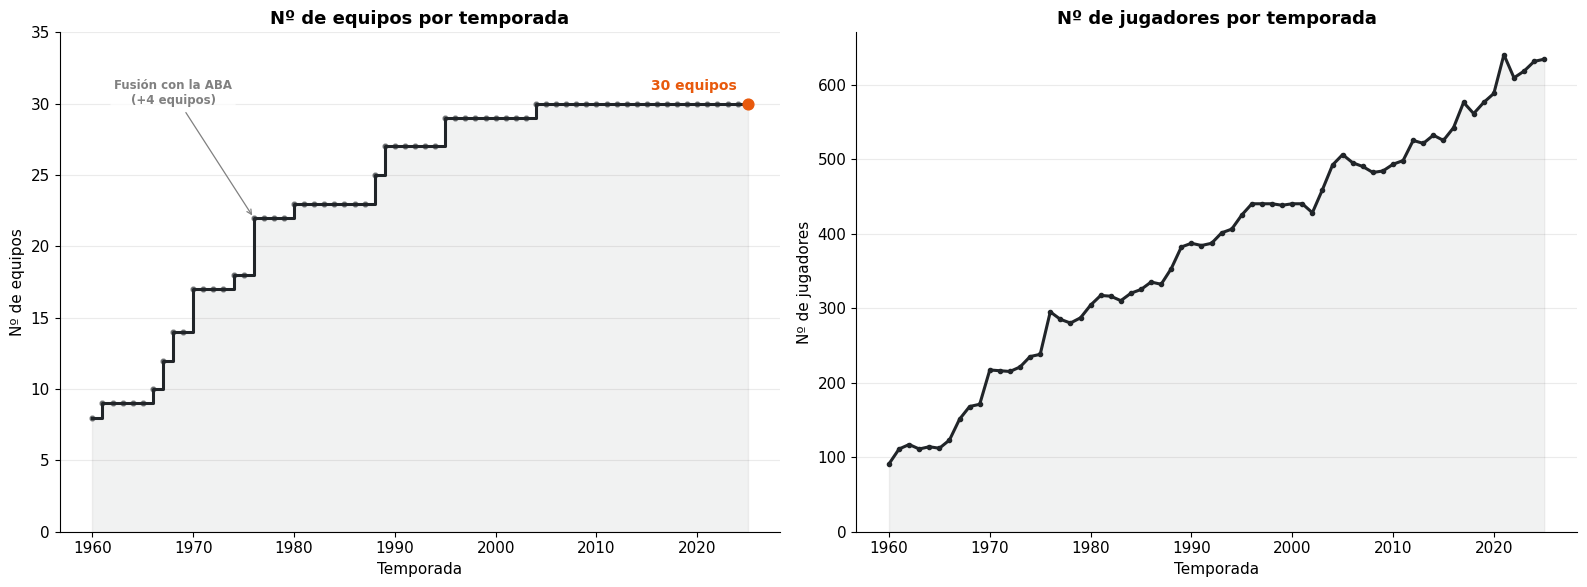

In [23]:
players_per_season = df.groupby('season')['personId'].nunique().reset_index()
players_per_season.columns = ['season', 'n_players']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.step(teams_per_season['season'], teams_per_season['n_teams'], where='post',
        color=COLOR_FG, lw=2.2, zorder=3)
ax.fill_between(teams_per_season['season'], teams_per_season['n_teams'],
                 step='post', color=COLOR_FG, alpha=0.06)
ax.scatter(teams_per_season['season'], teams_per_season['n_teams'],
           color=COLOR_FG, s=12, zorder=4, alpha=0.5)

# Resaltar el último punto (valor actual)
last = teams_per_season.iloc[-1]
ax.scatter(last['season'], last['n_teams'], color=COLOR_3P, s=60, zorder=5)
ax.annotate(f"{int(last['n_teams'])} equipos", xy=(last['season'], last['n_teams']),
            xytext=(-8, 10), textcoords='offset points', ha='right',
            fontsize=10, fontweight='bold', color=COLOR_3P)

milestones = {
    1976: {'label': 'Fusión con la ABA\n(+4 equipos)', 'xytext': (1968, 30)}
}
for year, info in milestones.items():
    if year in teams_per_season['season'].values:
        y = teams_per_season.loc[teams_per_season['season'] == year, 'n_teams'].values[0]
        ax.annotate(info['label'], xy=(year, y), xytext=info['xytext'],
                    fontsize=8.5, color='grey', ha='center', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.75),
                    arrowprops=dict(arrowstyle='->', color='grey', lw=0.9))

ax.set_title('Nº de equipos por temporada')
ax.set_xlabel('Temporada')
ax.set_ylabel('Nº de equipos')
ax.set_ylim(0, teams_per_season['n_teams'].max() + 5)
ax.grid(axis='x', visible=False)

ax = axes[1]
ax.plot(players_per_season['season'], players_per_season['n_players'],
         color=COLOR_FG, lw=2.2, marker='o', ms=3)
ax.fill_between(players_per_season['season'], players_per_season['n_players'],
                 color=COLOR_FG, alpha=0.06)

ax.set_title('Nº de jugadores por temporada')
ax.set_xlabel('Temporada')
ax.set_ylabel('Nº de jugadores')
ax.set_ylim(0, players_per_season['n_players'].max() + 30)
ax.grid(axis='x', visible=False)

plt.tight_layout()
#plt.savefig('equipos_jugadores_temporadas.png', dpi=300, bbox_inches='tight') 
plt.show()

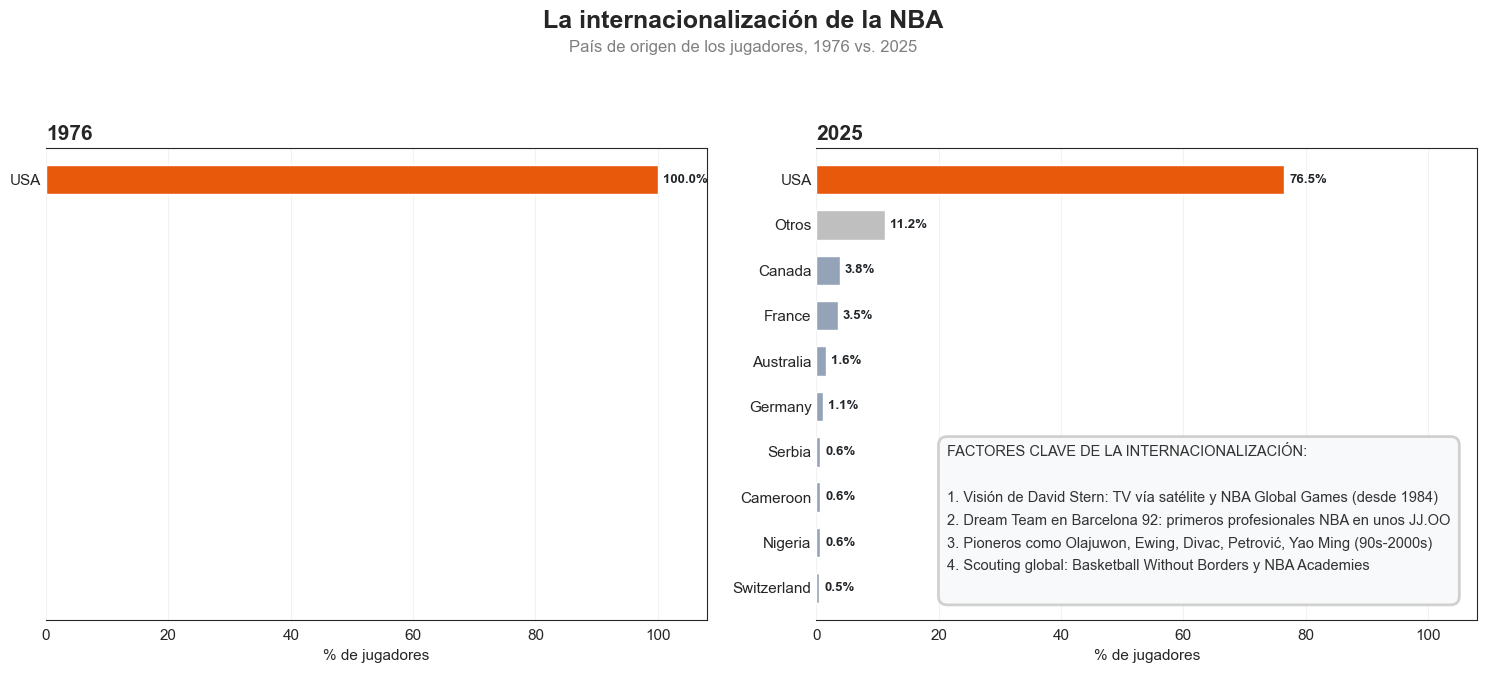

In [24]:
sns.set_style('white')

def get_top_countries_data(df, season, top_n=9):
    sub = df[df['season'] == season].dropna(subset=['country'])
    counts = sub['country'].value_counts()
    top = counts.head(top_n)
    other_countries = counts.iloc[top_n:]  
    others_sum = other_countries.sum()
    if others_sum > 0:
        top = pd.concat([top, pd.Series({'Otros': others_sum})])
    pct = (top / top.sum() * 100).sort_values(ascending=True)
    return pct, other_countries

seasons_to_plot = [1976, 2025]
data_by_season = {s: get_top_countries_data(df, s) for s in seasons_to_plot}

max_categories = max(len(pct) for pct, _ in data_by_season.values())
BAR_HEIGHT = 0.65


def plot_country_bars(pct, other_countries, season, ax):
    bar_colors = []
    for country in pct.index:
        if country == 'Otros':
            bar_colors.append((0.75, 0.75, 0.75))
        elif country == 'USA':
            bar_colors.append(COLOR_3P)
        else:
            bar_colors.append('#94A3B8')

    n = len(pct)
    y_pos = np.arange(max_categories - n, max_categories)

    bars = ax.barh(y_pos, pct.values, color=bar_colors, height=BAR_HEIGHT)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(pct.index)

    for bar, value in zip(bars, pct.values):
        ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
                f'{value:.1f}%', va='center', fontsize=9.5, fontweight='bold', color=COLOR_FG)

    ax.set_title(f'{int(season)}', fontsize=15, fontweight='bold', loc='left')
    ax.set_xlim(0, max(pct.max() for pct, _ in data_by_season.values()) + 8)
    ax.set_ylim(-0.7, max_categories - 0.3)
    ax.set_xlabel('% de jugadores')
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', alpha=0.25)
    ax.set_axisbelow(True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, season in zip(axes, seasons_to_plot):
    pct, other_countries = data_by_season[season]
    plot_country_bars(pct, other_countries, season, ax)

fig.suptitle('La internacionalización de la NBA', fontsize=18, fontweight='bold', y=1.03)
fig.text(0.5, 0.965, 'País de origen de los jugadores, 1976 vs. 2025',
          ha='center', fontsize=12, color='grey')

factores_texto = (
    "FACTORES CLAVE DE LA INTERNACIONALIZACIÓN: \n\n"
    "1. Visión de David Stern: TV vía satélite y NBA Global Games (desde 1984)\n"
    "2. Dream Team en Barcelona 92: primeros profesionales NBA en unos JJ.OO\n"
    "3. Pioneros como Olajuwon, Ewing, Divac, Petrović, Yao Ming (90s-2000s)\n"
    "4. Scouting global: Basketball Without Borders y NBA Academies\n"
)

axes[1].text(0.96, 0.05, factores_texto,
             transform=axes[1].transAxes,
             fontsize=10.5, va='bottom', ha='right', color='#333333',
             linespacing=1.8, multialignment='left',
             bbox=dict(boxstyle='round,pad=0.6', fc='#F8F9FA', ec='#CCCCCC', lw=2, alpha=0.9))

plt.tight_layout(rect=[0, 0, 1, 0.94])
#plt.savefig('internacionalizacion.png', dpi=300, bbox_inches='tight') 
plt.show()

In [25]:
# Volvemos a los parámetros originales para el resto de visualizaciones
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.axisbelow': True,
})

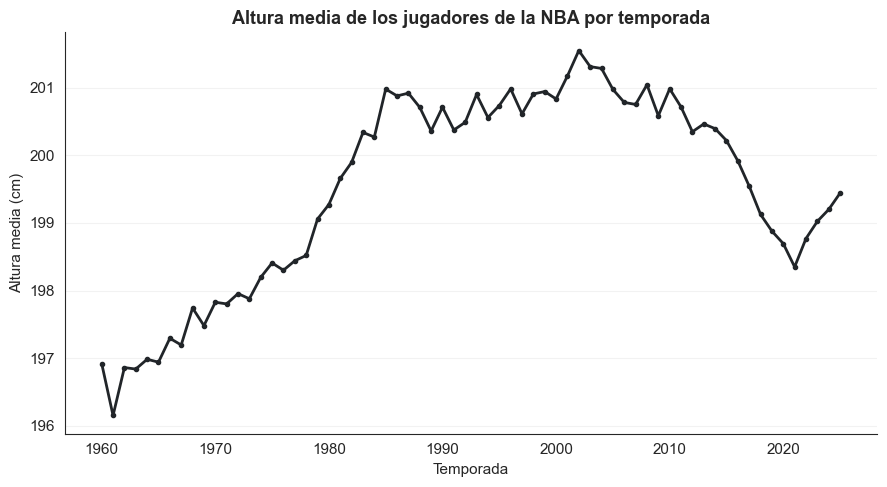

In [26]:
agg_season_h = df.dropna(subset=['height']).groupby('season')['height'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(agg_season_h['season'], agg_season_h['height'], color=COLOR_FG, lw=2, marker='o', ms=3)
ax.set_title('Altura media de los jugadores de la NBA por temporada')
ax.set_xlabel('Temporada')
ax.set_ylabel('Altura media (cm)')
ax.grid(axis='x', visible=False)
plt.tight_layout()
#plt.savefig('altura.png', dpi=300, bbox_inches='tight') 
plt.show()

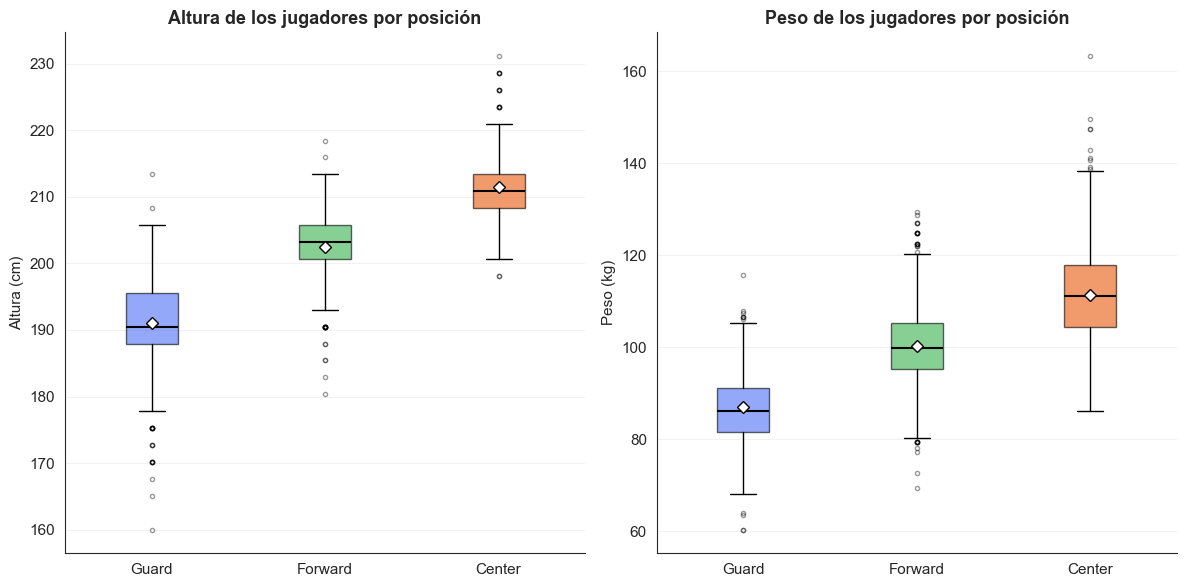

In [27]:
df_players = df.dropna(subset=['height', 'weight', 'position']).drop_duplicates(subset='personId')
positions = ['Guard', 'Forward', 'Center']
positions = [p for p in positions if p in df_players['position'].unique()]  

height_by_pos = [df_players.loc[df_players['position'] == p, 'height'] for p in positions]
weight_by_pos = [df_players.loc[df_players['position'] == p, 'weight'] for p in positions]
colors = [POS_COLORS[p] for p in positions]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
titles = ['Altura de los jugadores por posición',
          'Peso de los jugadores por posición']

for ax, data, ylabel, title in zip(axes, [height_by_pos, weight_by_pos],
                                    ['Altura (cm)', 'Peso (kg)'], titles):
    bp = ax.boxplot(data, tick_labels=positions, showmeans=True, patch_artist=True,
                     medianprops=dict(color='black', lw=1.5),
                     meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
                     flierprops=dict(marker='o', markersize=3, markerfacecolor='none', alpha=0.4))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis='x', visible=False)
plt.tight_layout()
#plt.savefig('alturapesohistorico.png', dpi=300, bbox_inches='tight') 
plt.show()

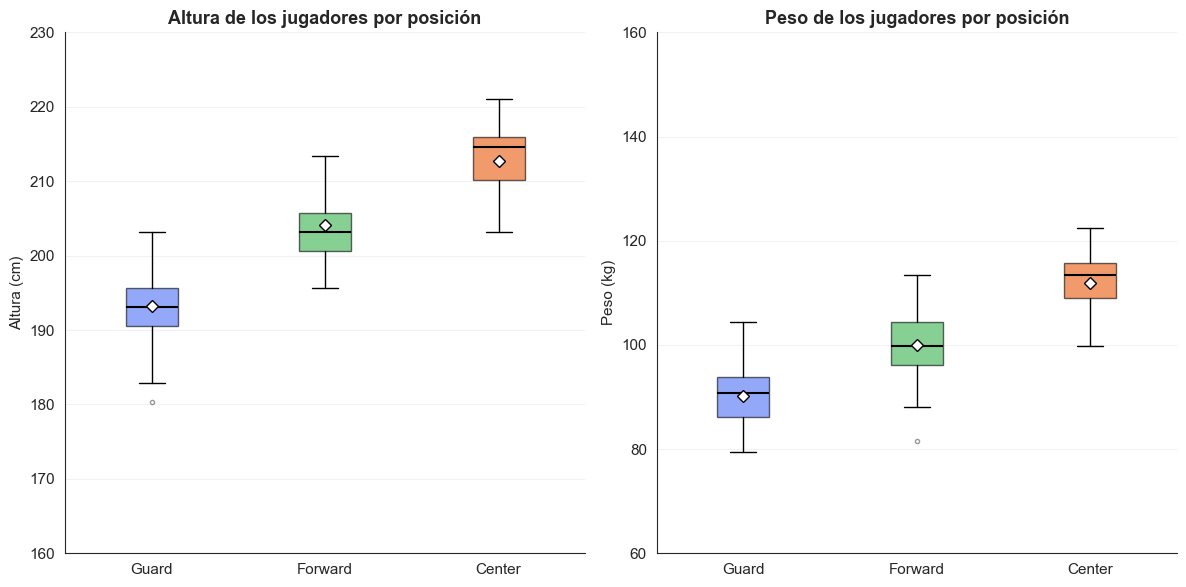

In [28]:
df_players = df.dropna(subset=['height', 'weight', 'position']).drop_duplicates(subset='personId')
df_players_actuales = df_players[df_players['season'] == df_players['season'].max()]
positions = ['Guard', 'Forward', 'Center']
positions = [p for p in positions if p in df_players['position'].unique()] 

height_by_pos = [df_players_actuales.loc[df_players_actuales['position'] == p, 'height'] for p in positions]
weight_by_pos = [df_players_actuales.loc[df_players_actuales['position'] == p, 'weight'] for p in positions]
colors = [POS_COLORS[p] for p in positions]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
titles = ['Altura de los jugadores por posición',
          'Peso de los jugadores por posición']

#Igualamos los yticks con el gráfico previo para poder comparar mejor la evolución de altura y peso por posición
yticks_ranges = [np.arange(160, 240, 10), np.arange(60, 170, 20)]

for ax, data, ylabel, title, yticks in zip(axes, [height_by_pos, weight_by_pos],
                                            ['Altura (cm)', 'Peso (kg)'], titles, yticks_ranges):
    bp = ax.boxplot(data, tick_labels=positions, showmeans=True, patch_artist=True,
                     medianprops=dict(color='black', lw=1.5),
                     meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
                     flierprops=dict(marker='o', markersize=3, markerfacecolor='none', alpha=0.4))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_yticks(yticks)
    ax.grid(axis='x', visible=False)

plt.tight_layout()
#plt.savefig('alturapeso2025.png', dpi=300, bbox_inches='tight') 
plt.show()

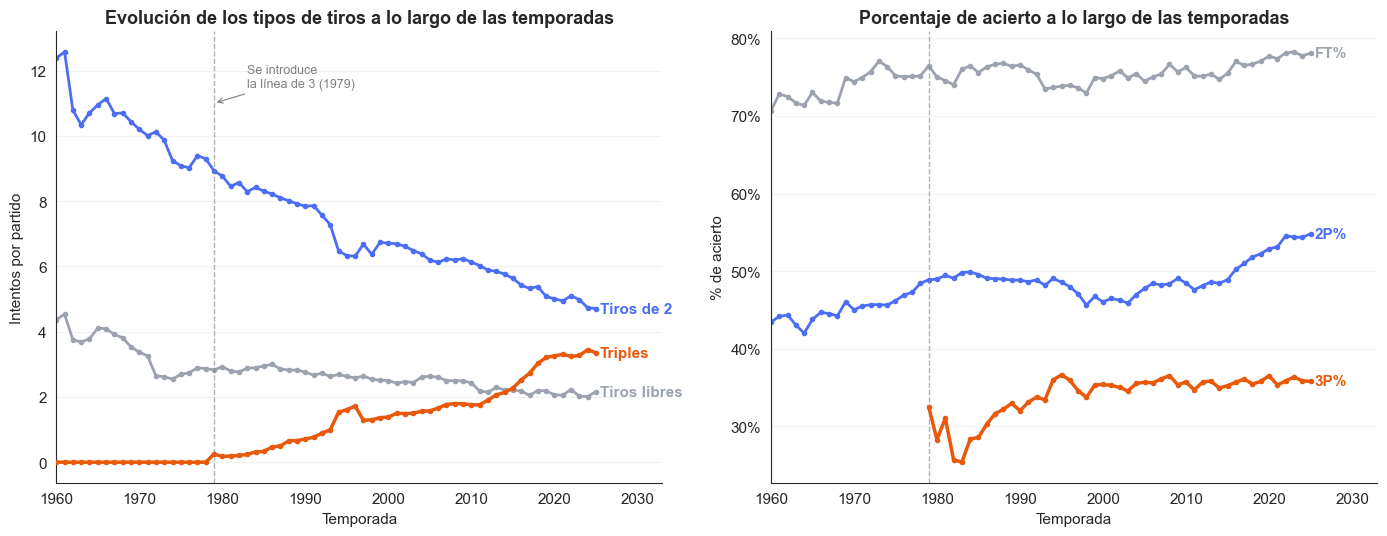

In [29]:
agg = df.groupby('season').agg(
    fgMade=('fieldGoalsMade', 'sum'),
    fgAtt=('fieldGoalsAttempted', 'sum'),
    twoMade=('twoPointersMade', 'sum'),
    twoAtt=('twoPointersAttempted', 'sum'),
    threeMade=('threePointersMade', 'sum'),
    threeAtt=('threePointersAttempted', 'sum'),
    ftMade=('freeThrowsMade', 'sum'),
    ftAtt=('freeThrowsAttempted', 'sum'),
    games=('gamesPlayed', 'sum'),
).reset_index()

agg['two_pct']   = agg['twoMade']   / agg['twoAtt']
agg['three_pct'] = agg['threeMade'] / agg['threeAtt']
agg['ft_pct']    = agg['ftMade']    / agg['ftAtt']

agg['two_per_game']   = agg['twoAtt']   / agg['games']
agg['three_per_game'] = agg['threeAtt'] / agg['games']
agg['ft_per_game']    = agg['ftAtt']    / agg['games']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.plot(agg['season'], agg['two_per_game'], color=COLOR_2P, lw=2, marker='o', ms=3)
ax.plot(agg['season'], agg['ft_per_game'],  color=COLOR_FT, lw=2, marker='o', ms=3)
ax.plot(agg['season'], agg['three_per_game'], color=COLOR_3P, lw=2.5, marker='o', ms=3, zorder=5)

last = agg.iloc[-1]
ax.text(last['season']+0.5, last['two_per_game'], 'Tiros de 2', color=COLOR_2P, va='center', fontweight='bold')
ax.text(last['season']+0.5, last['ft_per_game'],  'Tiros libres', color=COLOR_FT, va='center', fontweight='bold')
ax.text(last['season']+0.5, last['three_per_game'], 'Triples', color=COLOR_3P, va='center', fontweight='bold')

ax.axvline(1979, color='grey', ls='--', lw=1, alpha=0.6)
ax.annotate('Se introduce\nla línea de 3 (1979)', xy=(1979, 11), xytext=(1983, 11.5),
            fontsize=9, color='grey', arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

ax.set_title('Evolución de los tipos de tiros a lo largo de las temporadas')
ax.set_xlabel('Temporada')
ax.set_ylabel('Intentos por partido')
ax.set_xlim(agg['season'].min(), agg['season'].max()+8)
ax.grid(axis='x', visible=False)

ax = axes[1]
ax.plot(agg['season'], agg['two_pct'], color=COLOR_2P, lw=2, marker='o', ms=3)
ax.plot(agg['season'], agg['three_pct'], color=COLOR_3P, lw=2.5, marker='o', ms=3, zorder=5)
ax.plot(agg['season'], agg['ft_pct'],  color=COLOR_FT, lw=2, marker='o', ms=3)

ax.text(last['season']+0.5, last['two_pct'], '2P%', color=COLOR_2P, va='center', fontweight='bold')
ax.text(last['season']+0.5, last['three_pct'], '3P%', color=COLOR_3P, va='center', fontweight='bold')
ax.text(last['season']+0.5, last['ft_pct'],  'FT%', color=COLOR_FT, va='center', fontweight='bold')
ax.axvline(1979, color='grey', ls='--', lw=1, alpha=0.6)

ax.set_title('Porcentaje de acierto a lo largo de las temporadas')
ax.set_xlabel('Temporada')
ax.set_ylabel('% de acierto')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlim(agg['season'].min(), agg['season'].max()+8)
ax.grid(axis='x', visible=False)

plt.tight_layout()
#plt.savefig('anotacion.png', dpi=300, bbox_inches='tight') 
plt.show()

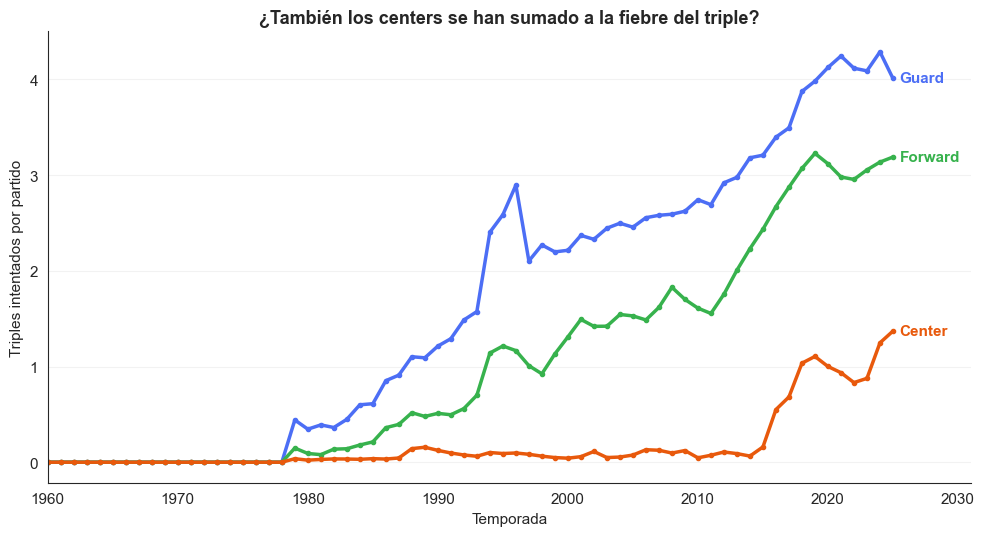

In [30]:
agg_pos_season = df.dropna(subset=['position']).groupby(['season', 'position']).agg(
    threeAtt=('threePointersAttempted', 'sum'),
    games=('gamesPlayed', 'sum'),
).reset_index()
agg_pos_season['three_per_game'] = agg_pos_season['threeAtt'] / agg_pos_season['games']

fig, ax = plt.subplots(figsize=(10, 5.5))
for p in positions:
    sub = agg_pos_season[agg_pos_season['position'] == p].sort_values('season')
    ax.plot(sub['season'], sub['three_per_game'], color=POS_COLORS[p], lw=2.5, marker='o', ms=3)
    last = sub.iloc[-1]
    ax.text(last['season']+0.5, last['three_per_game'], p, color=POS_COLORS[p], fontweight='bold', va='center')

ax.set_title('¿También los centers se han sumado a la fiebre del triple?')
ax.set_xlabel('Temporada')
ax.set_ylabel('Triples intentados por partido')
ax.set_xlim(agg_pos_season['season'].min(), agg_pos_season['season'].max()+6)
ax.grid(axis='x', visible=False)
plt.tight_layout()
#plt.savefig('triple.png', dpi=300, bbox_inches='tight') 
plt.show()

## VISUALIZACIÓN DINÁMICA


In [31]:
df

,personId,firstName,lastName,season,numMinutes,points,assists,blocks,steals,turnovers,foulsPersonal,reboundsOffensive,reboundsDefensive,reboundsTotal,plusMinusPoints,fieldGoalsMade,fieldGoalsAttempted,threePointersMade,threePointersAttempted,freeThrowsMade,freeThrowsAttempted,gamesPlayed,teams,wins,fieldGoalsPercentage,threePointersPercentage,freeThrowsPercentage,twoPointersMade,twoPointersAttempted,twoPointersPercentage,fullName,numTeams,birthYear,school,country,draftYear,draftRound,position,age,height,weight
0,2.0,Byron,Scott,1983.0,21.712766,10.202128,2.234043,0.223404,1.053191,1.510638,2.265957,0.648936,1.489362,2.138298,0.000000,408.0,851.0,10.0,44.0,133.0,174.0,94,[Lakers],63.0,0.479436,0.227273,0.764368,398.0,807.0,0.493185,Byron Scott,1,1961.0,Arizona State,USA,1983.0,1.0,Guard,22.0,193.04,92.98636
1,2.0,Byron,Scott,1984.0,28.900000,16.160000,2.930000,0.210000,1.390000,1.590000,2.450000,0.730000,1.890000,2.620000,0.000000,679.0,1270.0,36.0,81.0,222.0,272.0,100,[Lakers],76.0,0.534646,0.444444,0.816176,643.0,1189.0,0.540791,Byron Scott,1,1961.0,Arizona State,USA,1983.0,1.0,Guard,23.0,193.04,92.98636
2,2.0,Byron,Scott,1985.0,29.488889,15.533333,2.288889,0.188889,1.155556,1.555556,2.277778,0.777778,1.933333,2.711111,0.000000,597.0,1170.0,28.0,78.0,176.0,218.0,90,[Lakers],65.0,0.510256,0.358974,0.807339,569.0,1092.0,0.521062,Byron Scott,1,1961.0,Arizona State,USA,1983.0,1.0,Guard,24.0,193.04,92.98636
3,2.0,Byron,Scott,1986.0,33.370000,16.630000,3.410000,0.220000,1.440000,1.690000,2.150000,0.830000,2.650000,3.480000,0.000000,657.0,1344.0,72.0,183.0,277.0,318.0,100,[Lakers],80.0,0.488839,0.393443,0.871069,585.0,1161.0,0.503876,Byron Scott,1,1961.0,Arizona State,USA,1983.0,1.0,Guard,25.0,193.04,92.98636
4,2.0,Byron,Scott,1987.0,37.571429,21.180952,3.752381,0.304762,1.800000,1.980952,2.571429,0.971429,3.152381,4.123810,0.000000,888.0,1705.0,86.0,234.0,362.0,421.0,105,[Lakers],77.0,0.520821,0.367521,0.859857,802.0,1471.0,0.545207,Byron Scott,1,1961.0,Arizona State,USA,1983.0,1.0,Guard,26.0,193.04,92.98636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25811,1643141.0,Jahmyl,Telfort,2025.0,5.174000,1.000000,0.100000,0.000000,0.100000,0.200000,0.700000,0.100000,0.500000,0.600000,-1.800000,4.0,12.0,1.0,8.0,1.0,4.0,10,[Clippers],6.0,0.333333,0.125000,0.250000,3.0,4.0,0.750000,Jahmyl Telfort,1,2001.0,-,Canada,-1.0,-1.0,Guard,24.0,200.66,NaN
25812,1643148.0,Saint,Thomas,2025.0,2.220000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.0,0.0,0.0,0.0,0.0,0.0,1,[76ers],1.0,NaN,NaN,NaN,0.0,0.0,NaN,Saint Thomas,1,2003.0,USC,USA,-1.0,-1.0,NaN,22.0,NaN,NaN
25813,1643158.0,Andersson,Garcia,2025.0,33.690000,5.200000,2.800000,0.800000,1.600000,1.400000,3.200000,3.400000,5.000000,8.400000,-7.400000,9.0,29.0,1.0,13.0,7.0,9.0,5,[Jazz],1.0,0.310345,0.076923,0.777778,8.0,16.0,0.500000,Andersson Garcia,1,2000.0,Texas A&M,Dominican Republic,-1.0,-1.0,Forward,25.0,200.66,99.79024
25814,1643253.0,Toby,Okani,2025.0,35.908333,10.000000,1.000000,0.500000,0.666667,0.500000,3.333333,1.500000,2.000000,3.500000,-22.833333,25.0,70.0,9.0,31.0,1.0,8.0,6,[Grizzlies],0.0,0.357143,0.290323,0.125000,16.0,39.0,0.410256,Toby Okani,1,2001.0,West Virginia,USA,-1.0,-1.0,Forward,24.0,203.20,95.25432


### MAPA


In [32]:
ESTADOS = {
    'Alabama': [
        'Alabama',
        'Alabama A&M',
        'Alabama Huntsville',
        'Alabama State',
        'Alabama-Birmingham',
        'Auburn',
        'Auburn-Montgomery',
        'Jacksonville State',
        'Miles',
        'Montevallo',
        'South Alabama',
        'Tuskegee',
    ],
    'Arizona': [
        'Arizona',
        'Arizona State',
        'Grand Canyon',
        'Northern Arizona',
    ],
    'Arkansas': [
        'Arkansas',
        'Arkansas-Little Rock',
        'Central Arkansas',
        'Ouachita Baptist',
    ],
    'California': [
        'Cal Poly-Obispo',
        'Cal State-Fullerton',
        'Cal State-Long Beach',
        'Cal-Davis',
        'Cal-Santa Barbara',
        'California',
        'California State-Bakersfield',
        'California State-Fullerton',
        'California State-Los Angeles',
        'California State-Northridge',
        'California State-Poly Pomona',
        'California State-San Bernardino',
        'California-Irvine',
        'California-San Diego',
        'California-Santa Barbara',
        'Fresno State',
        'Long Beach State',
        'Loyola-Marymount',
        'Mt. San Antonio',
        'Pacific',
        'Pepperdine',
        'Point Loma',
        "Saint Mary's",
        'San Diego',
        'San Diego State',
        'San Francisco',
        'San Jose State',
        'Santa Clara',
        'Southern California',
        "St. Mary's",
        "St. Mary's (CA)",
        "St. Mary's College",
        'Stanford',
        "The Master's College",
        'UCLA',
        'USC',
    ],
    'Carolina del Norte': [
        'Appalachian State',
        'Belmont Abbey',
        'Campbell',
        'Campbell University',
        'Davidson',
        'Duke',
        'East Carolina',
        'Elizabeth City State',
        'Elon',
        'Fayetteville State',
        'Gardner-Webb',
        'Guilford',
        'Johnson C. Smith',
        'North Carolina',
        'North Carolina A&T',
        'North Carolina Central',
        'North Carolina State',
        'North Carolina-Charlotte',
        'North Carolina-Wilmington',
        'Pfeiffer',
        'Shaw',
        "St. Augustine's",
        'UNC-Greensboro',
        'UNC-Wilmington',
        'Wake Forest',
        'Western Carolina',
        'Wingate',
        'Winston-Salem',
        'Winston-Salem State',
    ],
    'Carolina del Sur': [
        'Charleston',
        'Clemson',
        'College of Charleston',
        'Friendship (SC)',
        'Furman',
        'South Carolina',
        'South Carolina State',
        'South Carolina Upstate',
        'Voorhees',
        'Winthrop',
    ],
    'Colorado': [
        'Colorado',
        'Colorado State',
        'Denver',
        'Northern Colorado',
        'University of Colorado Boulder',
    ],
    'Connecticut': [
        'Bridgeport',
        'Central Connecticut State',
        'Connecticut',
        'Fairfield',
        'Hartford',
        'Yale',
    ],
    'Dakota del Norte': [
        'North Dakota',
    ],
    'Dakota del Sur': [
        'Augustana (SD)',
        'South Dakota State',
    ],
    'Delaware': [
        'Delaware',
        'Delaware State',
    ],
    'Florida': [
        'Central Florida',
        'Florida',
        'Florida A&M',
        'Florida Gulf Coast',
        'Florida International',
        'Florida State',
        'Jacksonville',
        'Miami',
        'Northwest Florida State',
        'South Florida',
        'St. Thomas (FL)',
        'Stetson',
        'Tampa',
        'UCF',
        'West Florida',
    ],
    'Georgia': [
        'Albany State (GA)',
        'Augusta State',
        'Fort Valley State',
        'Georgia',
        'Georgia Southern',
        'Georgia State',
        'Georgia Tech',
        'Mercer',
        'Morehouse',
        'West Georgia',
    ],
    'Hawái': [
        'Brigham Young-Hawaii',
        'Hawaii',
    ],
    'Idaho': [
        'Boise State',
        'Idaho',
        'Idaho State',
    ],
    'Illinois': [
        'Aurora',
        'Bradley',
        'Chicago St.',
        'DePaul',
        'Eastern Illinois',
        'Illinois',
        'Illinois State',
        'Illinois Wesleyan',
        'Illinois-Chicago',
        'Illinois-Urbana-Champaign',
        'John A. Logan',
        'Lewis',
        'Loyola (IL)',
        'Loyola-Chicago',
        'North Park',
        'Northern Illinois',
        'Northwestern',
        'Robert Morris-Chicago',
        'Southeastern Illinois',
        'Southern Illinois',
        'Wheaton',
    ],
    'Indiana': [
        'Ball State',
        'Butler',
        'Evansville',
        'Indiana',
        'Indiana State',
        'Indiana-Purdue Fort Wayne',
        'Indiana-Purdue Indianapolis',
        'Indianapolis',
        'Notre Dame',
        'Purdue',
        'Valparaiso',
    ],
    'Iowa': [
        'Drake',
        'Indian Hills C.C.',
        'Iowa',
        'Iowa State',
        'Northern Iowa',
    ],
    'Kansas': [
        'Butler C.C. (KS)',
        'Kansas',
        'Kansas State',
        'Seward County CC',
        'Wichita State',
    ],
    'Kentucky': [
        'Eastern Kentucky',
        'Kentucky',
        'Kentucky State',
        'Kentucky Wesleyan',
        'Louisville',
        'Morehead State',
        'Murray State',
        'Pikeville',
        'Thomas More',
        'Western Kentucky',
    ],
    'Luisiana': [
        'Centenary-Louisiana',
        'Dillard',
        'Grambling',
        'Louisana-Lafayette',
        'Louisiana State',
        'Louisiana Tech',
        'Louisiana-Lafayette',
        'Louisiana-Monroe',
        'Mc Neese State',
        'McNeese State',
        'New Orleans',
        'Nicholls State',
        'Northwestern State',
        'Southern',
        'Tulane',
        'Xavier of Louisiana',
    ],
    'Maine': [
        'Maine',
    ],
    'Maryland': [
        'Baltimore',
        'Coppin State',
        'Loyola-Maryland',
        'Maryland',
        'Maryland-Eastern Shore',
        'Morgan State',
        "Mount St. Mary's",
        'Navy',
        'Towson',
    ],
    'Massachusetts': [
        'American International',
        'Assumption',
        'Boston College',
        'Boston U.',
        'Boston University',
        'Harvard',
        'Holy Cross',
        'Massachusetts',
        'Northeastern',
    ],
    'Michigan': [
        'Central Michigan',
        'Detroit',
        'Detroit Mercy',
        'Eastern Michigan',
        'Hillsdale',
        'Michigan',
        'Michigan State',
        'Oakland',
        'Western Michigan',
    ],
    'Minnesota': [
        'Bethel',
        'Minnesota',
        'Minnesota-Duluth',
    ],
    'Misisipi': [
        'Alcorn State',
        'Delta State',
        'Jackson State',
        'Meridian CC',
        'Mississippi',
        'Mississippi State',
        'Mississippi Valley State',
        'Northeast Mississippi CC',
        'Southern Mississippi',
    ],
    'Misuri': [
        'Lincoln (MO)',
        'Missouri',
        'Missouri State',
        'Missouri-Kansas City',
        'Northwest Missouri St.',
        'S.E. Missouri',
        'Southeast Missouri',
        'St. Louis',
        'Truman State',
    ],
    'Montana': [
        'Montana',
        'Montana State',
    ],
    'Nebraska': [
        'Creighton',
        'Nebraska',
        'Nebraska-Kearney',
        'Nebraska-Lincoln',
    ],
    'Nevada': [
        'Nevada',
        'Nevada-Reno',
        'UNLV',
    ],
    'Nueva Jersey': [
        'College of New Jersey',
        'Monmouth',
        'Princeton',
        'Rider',
        'Rutgers',
        'Seton Hall',
        "St. Peter's",
        'William Paterson',
    ],
    'Nueva York': [
        'Army',
        'Buffalo',
        'Buffalo State',
        'Canisius',
        'Colgate',
        'Columbia',
        'Cornell',
        'Fordham',
        'Hofstra',
        'Iona',
        'Long Island-Brooklyn',
        'Manhattan',
        'Marist',
        'Molloy',
        'New York University',
        'Niagara',
        'Rochester',
        'SUNY-Potsdam',
        'Siena',
        'St. Bonaventure',
        "St. John's",
        "St. John's (NY)",
        "St. John's, N.Y.",
        'St. Rose',
        'Stony Brook',
        'Syracuse',
        'Wagner',
        'Westchester C.C.',
    ],
    'Nuevo Hampshire': [
        'Dartmouth',
    ],
    'Nuevo México': [
        'Eastern New Mexico',
        'New Mexico',
        'New Mexico Highlands',
        'New Mexico State',
    ],
    'Ohio': [
        'Akron',
        'Bowling Green',
        'Central State',
        'Cincinnati',
        'Cleveland State',
        'Dayton',
        'Kent State',
        'Kenyon',
        'Miami (Ohio)',
        'Ohio',
        'Ohio State',
        'Ohio Wesleyan',
        'Toledo',
        'University of Dayton',
        'Walsh',
        'Wilberforce',
        'Wright State',
        'Xavier',
    ],
    'Oklahoma': [
        'Central Oklahoma',
        'Northeastern State',
        'Nortwestern Oklahoma State',
        'Oklahoma',
        'Oklahoma Baptist',
        'Oklahoma City',
        'Oklahoma State',
        'Oral Roberts',
        'Phillips',
        'Southeastern Oklahoma State',
        'Tulsa',
    ],
    'Oregon': [
        'Oregon',
        'Oregon State',
        'Portland',
        'Portland State',
    ],
    'Pensilvania': [
        'Bucknell',
        'California (PA)',
        'Cheyney',
        'Drexel',
        'Duquesne',
        'La Salle',
        'Lehigh',
        'Millersville',
        'Penn State',
        'Pennsylvania',
        'Pittsburgh',
        'Slippery Rock',
        'St. Francis (PA)',
        "St. Joseph's (PA)",
        'St. Vincent',
        'Temple',
        'Villanova',
    ],
    'Rhode Island': [
        'Providence',
        'Rhode Island',
    ],
    'Tennessee': [
        'Austin Peay',
        'Belmont',
        'East Tennessee State',
        'Lincoln Memorial',
        'Lipscomb',
        'Memphis',
        'Memphis State',
        'Middle Tennessee State',
        'Tennessee',
        'Tennessee State',
        'Tennessee Tech',
        'Tennessee-Chattanooga',
        'Tennessee-Martin',
        'Vanderbilt',
    ],
    'Texas': [
        'Baylor',
        'Blinn J.C.',
        'Hardin-Simmons',
        'Houston',
        'Houston Baptist',
        'Lamar',
        'Midland (Texas)',
        'Midwestern State',
        'North Texas',
        'Prairie View A&M',
        'Rice',
        'Southern Methodist',
        'Southwest Texas State',
        "St. Mary's (TX)",
        'Stephen F. Austin',
        'TCU',
        'Texas',
        'Texas A&M',
        'Texas A&M-Commerce',
        'Texas Christian',
        'Texas Southern',
        'Texas State',
        'Texas Tech',
        'Texas-Arlington',
        'Texas-Austin',
        'Texas-El Paso',
        'Texas-Pan American',
        'Texas-San Antonio',
        'University of Texas at Austin',
        'West Texas A&M',
    ],
    'Utah': [
        'Brigham Young',
        'Southern Utah',
        'Utah',
        'Utah State',
        'Utah Valley',
        'Weber State',
    ],
    'Vermont': [
        'Vermont',
    ],
    'Virginia': [
        'Averett',
        'Christopher Newport',
        'George Mason',
        'Hampton',
        'James Madison',
        'Liberty',
        'Longwood',
        'Norfolk State',
        'Old Dominion',
        'Radford',
        'Richmond',
        'Va Commonwealth',
        'Virginia',
        'Virginia Commonwealth',
        'Virginia Military Institute',
        'Virginia Tech',
        'Virginia Union',
        'William & Mary',
    ],
    'Virginia Occidental': [
        'Marshall',
        'University of Charleston',
        'West Virginia',
        'West Virginia State',
        'West Virginia Tech',
        'West Virginia Wesleyan',
        'Wheeling Jesuit',
    ],
    'Washington': [
        'Eastern Washington',
        'Gonzaga',
        'Puget Sound',
        'Seattle',
        'Washington',
        'Washington State',
        'Whitworth',
    ],
    'Washington D.C.': [
        'American',
        'American University',
        'District of Columbia',
        'George Washington',
        'Georgetown',
        'Howard',
    ],
    'Wisconsin': [
        'Marquette',
        'Wisc.-Green Bay',
        'Wisconsin',
        'Wisconsin-Eau Claire',
        'Wisconsin-Green Bay',
        'Wisconsin-Milwaukee',
        'Wisconsin-Parkside',
        'Wisconsin-Stevens Point',
    ],
    'Wyoming': [
        'Wyoming',
    ],
}
 
PAISES = {
    'Alemania': [
        'Augsburg',
        'Bayern Munich',
        'Braunschweig',
        'Brose Bamberg',
        'DJK Wurzburg',
        'Germany',
        'Gottingen',
        'Ratiopharm Ulm',
        'RheinEnergie Cologne',
        'Riesen Ludwigsburg',
        'Skyliners Frankfurt',
    ],
    'Argentina': [
        'Cantera Instituto',
        'Estudiantes de Olavarria',
    ],
    'Australia': [
        'Adelaide',
        'Australian Institute of Sport',
        'Brisbane',
        'Illawarra',
        'Melbourne',
        'Rockingham Flames (Aus.)',
        'South East Melbourne',
        'Sydney',
        'Sydney Kings',
    ],
    'Brasil': [
        'Bauru',
        'Corinthians (Brazil)',
        'Flamengo',
        'Minas',
        'Pinheiros',
        'Ribeirao Preto',
        'Sao Carlos',
        'Vasco de Gama',
    ],
    'Bulgaria': [
        'Akademik Varna',
    ],
    'Bélgica': [
        'Spirou Charleroi',
        'Verviers-Pepinster',
    ],
    'Canadá': [
        'Acadia (CAN)',
        'Athlete Institute Prep',
        'Vanier',
        'Winnipeg Sea Bears',
    ],
    'China': [
        'Bayi',
        'Beijing',
        'Guangdong',
        'Guangzhou Loong Lions',
        'Shanghai',
        'Xinjiang',
    ],
    'Corea del Sur': [
        'Yonsei',
    ],
    'Croacia': [
        'Benston Zagreb',
        'Cedevita',
        'Cibona',
        'Split',
    ],
    'Cuba': [
        'Villa Clara',
    ],
    'Desconocido': [
        'Travajara',
    ],
    'Eslovenia': [
        'Union Olimpija',
    ],
    'España': [
        'Baloncesto Fuenlabrada',
        'Barcelona, Spain',
        'Baskonia',
        'Bilbao',
        'Cajasol Sevilla',
        'DKV Joventut',
        'Estudiantes',
        'FC Barcelona',
        'Gran Canaria',
        'Malaga',
        'Murcia',
        'Real Madrid',
        'Ricoh Manresa',
        'San Pablo Burgos',
        'Tau Ceramica',
        'Valencia',
        'WTC Cornella',
        'Zaragoza',
    ],
    'Francia': [
        'ADA Blois',
        'ASVEL',
        'Cholet',
        'Chorale Roanne',
        'Dijon',
        'Elan Bearnais',
        'Elan Chalon',
        'Hyeres-Toulon',
        'JL Bourg-en-Bresse',
        'Le Havre',
        'Le Mans',
        'Limoges',
        'Metropolitans 92',
        'Paris Basket Racing',
        'Pau Orthez',
        'Poitiers Basket 86',
        'Rouen, France',
        'Saint-Quentin',
        'Strasbourg IG',
    ],
    'Grecia': [
        'AEK Athens',
        'Aris',
        'Filathlitikos',
        'Olympiacos',
        'PAOK',
        'Panathinaikos',
        'Peristeri',
    ],
    'Hungría': [
        'Budapest AEH',
        'Sopron KC',
    ],
    'Irán': [
        'Saba Battery',
    ],
    'Israel': [
        'Maccabi Tel Aviv',
    ],
    'Italia': [
        'Angelico Biella',
        'Benetton Treviso',
        'Fortitudo Bologna',
        'Metis Varese',
        'Olimpia Milano',
        'Udine',
        'Victoria Libertas',
        'Virtus Bologna',
        'Virtus Roma',
    ],
    'Japón': [
        'Tokyo Apache',
        'Yokohama B-Corsairs (Japan)',
    ],
    'Letonia': [
        'BK Skonto',
        'VEF Riga',
    ],
    'Lituania': [
        'Atletas Kaunas',
        'Lietuvos rytas Vilnius',
        'Lithuania',
        'Statyba',
        'Zalgiris',
    ],
    'Montenegro': [
        'Buducnost',
    ],
    'Nueva Zelanda': [
        'New Zealand Breakers',
    ],
    'Polonia': [
        'Znicz Pruszkow',
    ],
    'Puerto Rico': [
        'Caguas',
    ],
    'Rusia': [
        'CSKA Moscow',
        'Khimki',
        'Zenit Saint Petersburg',
    ],
    'Serbia': [
        'Crvena zvezda',
        'FMP',
        'Hemoform',
        'Mega Basket',
        'Partizan',
        'Serbia',
    ],
    'Turquía': [
        'Anadolu Efes',
        'Beko',
        'Besiktas',
        'Bursaspor',
        'Darussafaka',
        'Efes Pilsen',
        'Fenerbahce',
        'Galatasaray',
        'Tofas S.K.',
        'Ulkerspor',
    ],
    'Ucrania': [
        'Donetsk',
        'Kyiv',
        'SK Cherkasy Monkey',
        'Stroitel',
        'Ukraine',
    ],
    'Uruguay': [
        'Penarol',
        'Trouville',
    ],
    'Venezuela': [
        'Trotamundos',
    ],
}
 

In [33]:
ESPECIALES = {
    'No College': ('Sin formación', 'Otros'),
    'NBA G League Ignite': ('Otros (G League Ignite)', 'Otros'),
    'G League Ignite': ('Otros (G League Ignite)', 'Otros'),
    'Overtime Elite': ('Georgia', 'Otros'),
    'Capital City Go-Go': ('Washington D.C.', 'Otros'),
    'Washington Wizards': ('Washington D.C.', 'Otros'),
    '-': ('Desconocido', 'Otros'),
    'NBA Global Academy': ('Australia', 'Internacional'),
}
ABREV_ESTADOS = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "DC": "Washington D.C.", "FL": "Florida", "GA": "Georgia", "HI": "Hawái",
    "ID": "Idaho", "IL": "Illinois", "IN": "Indiana", "IA": "Iowa",
    "KS": "Kansas", "KY": "Kentucky", "LA": "Luisiana", "ME": "Maine",
    "MD": "Maryland", "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota",
    "MS": "Misisipi", "MO": "Misuri", "MT": "Montana", "NE": "Nebraska",
    "NV": "Nevada", "NH": "Nuevo Hampshire", "NJ": "Nueva Jersey", "NM": "Nuevo México",
    "NY": "Nueva York", "NC": "Carolina del Norte", "ND": "Dakota del Norte", "OH": "Ohio",
    "OK": "Oklahoma", "OR": "Oregon", "PA": "Pensilvania", "RI": "Rhode Island",
    "SC": "Carolina del Sur", "SD": "Dakota del Sur", "TN": "Tennessee", "TX": "Texas",
    "UT": "Utah", "VT": "Vermont", "VA": "Virginia", "WA": "Washington",
    "WV": "Virginia Occidental", "WI": "Wisconsin", "WY": "Wyoming",
}
 
_ESCUELA_A_ESTADO = {n: est for est, lista in ESTADOS.items() for n in lista}
_CLUB_A_PAIS = {n: pais for pais, lista in PAISES.items() for n in lista}
_PATRON_INSTITUTO = re.compile(r"\bHS\b|Academy|Prep|School")
_PATRON_ABREV = re.compile(r"\(([A-Z]{2})\)\s*$")
 
 
def clasificar(school):
    if pd.isna(school):
        return ("Desconocido", "Otros")
    nombre = str(school).strip()
 
    if nombre in ESPECIALES:
        return ESPECIALES[nombre]
    if nombre in _CLUB_A_PAIS:
        return (_CLUB_A_PAIS[nombre], "Internacional")
 
    abrev = _PATRON_ABREV.search(nombre)
    if _PATRON_INSTITUTO.search(nombre) and abrev and abrev.group(1) in ABREV_ESTADOS:
        return (ABREV_ESTADOS[abrev.group(1)], "Instituto EE.UU.")
 
    if nombre in _ESCUELA_A_ESTADO:
        return (_ESCUELA_A_ESTADO[nombre], "Universidad EE.UU.")
 
    return ("Desconocido", "Sin mapear")
 
 
def agregar_formacion(df, columna="school"):
    """Añade las columnas 'formacion' y 'tipo' al dataframe."""
    resultado = df[columna].apply(clasificar)
    df["formacion"] = resultado.str[0]
    df["tipo"] = resultado.str[1]
 
    sin_mapear = df.loc[df["tipo"] == "Sin mapear", columna].unique()
    if len(sin_mapear):
        print(f"{len(sin_mapear)} valores sin mapear (añádelos a ESTADOS o PAISES):")
        for v in sin_mapear:
            print("  -", v)
    return df

VALORES_VACIOS = {"", "-", "desconocido", "nan", "none", "null", "n/a"}

def rellenar_con_country(df, columna="formacion", columna_pais="country"):
    vacia = df[columna].isna() | df[columna].astype(str).str.strip().str.lower().isin(VALORES_VACIOS)
    df.loc[vacia, columna] = df.loc[vacia, columna_pais]
    print(f"{vacia.sum()} filas rellenadas con {columna_pais}")
    return df

In [34]:
df = agregar_formacion(df, "school")
df = rellenar_con_country(df, "formacion", "country")

15 filas rellenadas con country


In [35]:
df.to_csv("dataframe_nba.csv", index=False)

In [36]:
pd.reset_option('display.max_rows')

In [37]:
ESTADOS_COD = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Washington D.C.": "DC", "Florida": "FL", "Georgia": "GA", "Hawái": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Luisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Misisipi": "MS", "Misuri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "Nuevo Hampshire": "NH", "Nueva Jersey": "NJ", "Nuevo México": "NM",
    "Nueva York": "NY", "Carolina del Norte": "NC", "Dakota del Norte": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pensilvania": "PA", "Rhode Island": "RI",
    "Carolina del Sur": "SC", "Dakota del Sur": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "Virginia Occidental": "WV", "Wisconsin": "WI", "Wyoming": "WY",
}
 
# ---------------------------------------------------------------
# 2. Códigos ISO-3 de países (nombre en español -> código)
# ---------------------------------------------------------------
PAISES_COD = {
    "España": "ESP", "Francia": "FRA", "Italia": "ITA", "Turquía": "TUR",
    "Serbia": "SRB", "Australia": "AUS", "Grecia": "GRC", "Alemania": "DEU",
    "Rusia": "RUS", "China": "CHN", "Lituania": "LTU", "Eslovenia": "SVN",
    "Brasil": "BRA", "Ucrania": "UKR", "Croacia": "HRV", "Israel": "ISR",
    "Montenegro": "MNE", "Canadá": "CAN", "Bélgica": "BEL", "Hungría": "HUN",
    "Argentina": "ARG", "Letonia": "LVA", "Nueva Zelanda": "NZL", "Japón": "JPN",
    "Uruguay": "URY", "Polonia": "POL", "Venezuela": "VEN", "Cuba": "CUB",
    "Puerto Rico": "PRI", "Irán": "IRN", "Bulgaria": "BGR", "Corea del Sur": "KOR",
    "Bosnia y Herzegovina": "BIH", "Macedonia del Norte": "MKD", "República Checa": "CZE",
    "Georgia (país)": "GEO", "Nigeria": "NGA", "Senegal": "SEN", "Camerún": "CMR",
    "Congo": "COD", "Sudán del Sur": "SSD", "México": "MEX", "República Dominicana": "DOM",
    "Bahamas": "BHS", "Jamaica": "JAM", "Panamá": "PAN", "Reino Unido": "GBR",
    "Suiza": "CHE", "Austria": "AUT", "Suecia": "SWE", "Finlandia": "FIN",
    "Dinamarca": "DNK", "Países Bajos": "NLD", "Portugal": "PRT",
    "Estonia": "EST", "Rumanía": "ROU", "Egipto": "EGY", "Túnez": "TUN",
    "Filipinas": "PHL", "India": "IND", "Mali": "MLI", "Guinea": "GIN",
}
 
# Valores que vienen de la columna country en inglés -> español
TRADUCCION = {
    "France": "Francia", "Brazil": "Brasil", "Greece": "Grecia", "Canada": "Canadá",
    "Spain": "España", "Italy": "Italia", "Germany": "Alemania", "Turkey": "Turquía",
    "Russia": "Rusia", "Lithuania": "Lituania", "Slovenia": "Eslovenia", "Ukraine": "Ucrania",
    "Croatia": "Croacia", "Belgium": "Bélgica", "Hungary": "Hungría", "Latvia": "Letonia",
    "New Zealand": "Nueva Zelanda", "Japan": "Japón", "Poland": "Polonia", "Iran": "Irán",
    "South Korea": "Corea del Sur", "Bosnia and Herzegovina": "Bosnia y Herzegovina",
    "North Macedonia": "Macedonia del Norte", "Czech Republic": "República Checa",
    "Cameroon": "Camerún", "DRC": "Congo", "Democratic Republic of the Congo": "Congo",
    "South Sudan": "Sudán del Sur", "Mexico": "México", "Dominican Republic": "República Dominicana",
    "Panama": "Panamá", "United Kingdom": "Reino Unido", "England": "Reino Unido",
    "Great Britain": "Reino Unido", "Switzerland": "Suiza", "Sweden": "Suecia",
    "Finland": "Finlandia", "Denmark": "Dinamarca", "Netherlands": "Países Bajos",
    "Romania": "Rumanía", "Egypt": "Egipto", "Tunisia": "Túnez", "Philippines": "Filipinas",
    "Bulgaria": "Bulgaria", "Serbia": "Serbia", "Australia": "Australia", "China": "China",
    "Israel": "Israel", "Montenegro": "Montenegro", "Argentina": "Argentina",
    "Uruguay": "Uruguay", "Venezuela": "Venezuela", "Cuba": "Cuba", "Puerto Rico": "Puerto Rico",
    "Nigeria": "Nigeria", "Senegal": "Senegal", "Jamaica": "Jamaica", "Bahamas": "Bahamas",
    "Austria": "Austria", "Portugal": "Portugal", "Estonia": "Estonia", "India": "India",
    "Mali": "Mali", "Guinea": "Guinea",
}

In [38]:
origen_jugadores=df.drop_duplicates(subset='personId')
origen_jugadores['school'].value_counts()

school
Kentucky                 112
Duke                      99
UCLA                      98
North Carolina            84
Kansas                    78
                        ... 
St. Mary's (CA)            1
ADA Blois                  1
Guangzhou Loong Lions      1
Washington Wizards         1
JL Bourg-en-Bresse         1
Name: count, Length: 657, dtype: int64

In [39]:
def preparar_conteo(df, columna="formacion"):
    conteo = (
        df[columna]
        .astype(str).str.strip()
        .replace(TRADUCCION)          
        .value_counts()
        .rename_axis("formacion")
        .reset_index(name="jugadores")
    )
    conteo["cod_estado"] = conteo["formacion"].map(ESTADOS_COD)
    conteo["cod_pais"] = conteo["formacion"].map(PAISES_COD)
    return conteo
 
 
conteo = preparar_conteo(origen_jugadores, "formacion")
 
estados = conteo[conteo["cod_estado"].notna()]
paises = conteo[conteo["cod_pais"].notna()]
fuera_mapa = conteo[conteo["cod_estado"].isna() & conteo["cod_pais"].isna()]
 
if len(fuera_mapa):
    print("No se pueden situar en el mapa:")
    print(fuera_mapa[["formacion", "jugadores"]].to_string(index=False))

No se pueden situar en el mapa:
              formacion  jugadores
Otros (G League Ignite)         15
          Sin formación          5
                    USA          3


In [40]:
max_jug = conteo.loc[conteo["cod_estado"].notna() | conteo["cod_pais"].notna(), "jugadores"].max()
ticks = [t for t in [1, 2, 5, 10, 25, 50, 100, 250, 500, 1000] if t <= max_jug * 1.5]
escala = "YlOrRd"
 
hover = "<b>%{customdata[0]}</b><br>Jugadores: %{customdata[1]}<extra></extra>"
 
fig = go.Figure()
 
# Resto del mundo (países)
fig.add_trace(go.Choropleth(
    locations=paises["cod_pais"],
    locationmode="ISO-3",
    z=np.log10(paises["jugadores"]),
    customdata=paises[["formacion", "jugadores"]],
    hovertemplate=hover,
    coloraxis="coloraxis",
    marker_line_color="white",
    marker_line_width=0.5,
    name="Países",
))
 
# EE.UU. dividido por estados
fig.add_trace(go.Choropleth(
    locations=estados["cod_estado"],
    locationmode="USA-states",
    z=np.log10(estados["jugadores"]),
    customdata=estados[["formacion", "jugadores"]],
    hovertemplate=hover,
    coloraxis="coloraxis",
    marker_line_color="white",
    marker_line_width=0.5,
    name="Estados EE.UU.",
))
 
fig.update_layout(
    title=dict(
        text="Origen de formación de los jugadores<br>"
             "<sup>Formación y llegada a la NBA (no nacimiento)</sup>",
        x=0.5,
    ),
    coloraxis=dict(
        colorscale=escala,
        cmin=0,
        cmax=np.log10(max_jug),
        colorbar=dict(
            title="Jugadores",
            tickvals=np.log10(ticks),
            ticktext=[str(t) for t in ticks],
        ),
    ),
    geo=dict(
        projection_type="natural earth",
        showframe=False,
        showcoastlines=True,
        coastlinecolor="#999999",
        showland=True,
        landcolor="#eeeeee",          # países sin jugadores
        showcountries=True,
        countrycolor="white",
        showlakes=False,
    ),
    margin=dict(l=0, r=0, t=70, b=0),
    height=600,
)
 
fig.write_html("mapa_formacion.html")
print("Mapa guardado en mapa_formacion.html")
 

Mapa guardado en mapa_formacion.html


### RESTO


In [41]:
df.groupby('season')['plusMinusPoints'].count()

season
1960.0     91
1961.0    111
1962.0    117
1963.0    111
1964.0    114
         ... 
2021.0    640
2022.0    609
2023.0    618
2024.0    631
2025.0    634
Name: plusMinusPoints, Length: 66, dtype: int64

In [42]:
pd.set_option('display.max_rows', 100)

In [47]:
df[df.formacion == 'Montana']

,personId,firstName,lastName,season,numMinutes,points,assists,blocks,steals,turnovers,foulsPersonal,reboundsOffensive,reboundsDefensive,reboundsTotal,plusMinusPoints,fieldGoalsMade,fieldGoalsAttempted,threePointersMade,threePointersAttempted,freeThrowsMade,freeThrowsAttempted,gamesPlayed,teams,wins,fieldGoalsPercentage,threePointersPercentage,freeThrowsPercentage,twoPointersMade,twoPointersAttempted,twoPointersPercentage,fullName,numTeams,birthYear,school,country,draftYear,draftRound,position,age,height,weight,formacion,tipo
5123,1474.0,Larry,Krystkowiak,1986.0,14.764706,6.632353,1.250000,0.176471,0.323529,0.985294,2.073529,1.132353,2.382353,3.514706,0.000000,170.0,373.0,1.0,12.0,110.0,148.0,68,[Spurs],23.0,0.455764,0.083333,0.743243,169.0,361.0,0.468144,Larry Krystkowiak,1,1964.0,Montana,USA,1986.0,2.0,Forward,22.0,205.74,99.790240,Montana,Universidad EE.UU.
5124,1474.0,Larry,Krystkowiak,1987.0,22.054545,7.290909,1.036364,0.145455,0.400000,1.127273,2.800000,1.836364,2.981818,4.818182,0.000000,141.0,295.0,0.0,3.0,119.0,145.0,55,[Bucks],26.0,0.477966,0.000000,0.820690,141.0,292.0,0.482877,Larry Krystkowiak,1,1964.0,Montana,USA,1986.0,2.0,Forward,23.0,205.74,99.790240,Montana,Universidad EE.UU.
5125,1474.0,Larry,Krystkowiak,1988.0,30.806818,12.522727,1.352273,0.113636,1.079545,1.852273,2.738636,2.409091,5.034091,7.443182,0.000000,391.0,834.0,4.0,14.0,316.0,382.0,88,[Bucks],50.0,0.468825,0.285714,0.827225,387.0,820.0,0.471951,Larry Krystkowiak,1,1964.0,Montana,USA,1986.0,2.0,Forward,24.0,205.74,99.790240,Montana,Universidad EE.UU.
5126,1474.0,Larry,Krystkowiak,1989.0,23.812500,7.000000,1.562500,0.125000,0.625000,1.187500,2.562500,1.000000,3.750000,4.750000,0.000000,43.0,118.0,0.0,2.0,26.0,33.0,16,[Bucks],9.0,0.364407,0.000000,0.787879,43.0,116.0,0.370690,Larry Krystkowiak,1,1964.0,Montana,USA,1986.0,2.0,Forward,25.0,205.74,99.790240,Montana,Universidad EE.UU.
5127,1474.0,Larry,Krystkowiak,1990.0,8.333333,0.666667,0.666667,0.000000,0.333333,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.0,6.0,0.0,0.0,0.0,0.0,3,[Bucks],0.0,0.166667,NaN,NaN,1.0,6.0,0.166667,Larry Krystkowiak,1,1964.0,Montana,USA,1986.0,2.0,Forward,26.0,205.74,99.790240,Montana,Universidad EE.UU.
5128,1474.0,Larry,Krystkowiak,1991.0,23.392405,9.025316,1.443038,0.151899,0.683544,1.455696,2.759494,1.658228,3.772152,5.430380,0.000000,293.0,660.0,0.0,5.0,127.0,169.0,79,[Bucks],30.0,0.443939,0.000000,0.751479,293.0,655.0,0.447328,Larry Krystkowiak,1,1964.0,Montana,USA,1986.0,2.0,Forward,27.0,205.74,99.790240,Montana,Universidad EE.UU.
5129,1474.0,Larry,Krystkowiak,1992.0,19.027778,7.125000,0.944444,0.180556,0.583333,0.875000,2.527778,1.041667,2.861111,3.902778,0.000000,198.0,426.0,0.0,1.0,117.0,147.0,72,[Jazz],41.0,0.464789,0.000000,0.795918,198.0,425.0,0.465882,Larry Krystkowiak,1,1964.0,Montana,USA,1986.0,2.0,Forward,28.0,205.74,99.790240,Montana,Universidad EE.UU.
5130,1474.0,Larry,Krystkowiak,1993.0,20.918919,5.162162,1.189189,0.162162,0.459459,0.837838,2.270270,1.216216,2.783784,4.000000,0.000000,78.0,166.0,0.0,1.0,35.0,43.0,37,[Magic],21.0,0.469880,0.000000,0.813953,78.0,165.0,0.472727,Larry Krystkowiak,1,1964.0,Montana,USA,1986.0,2.0,Forward,29.0,205.74,99.790240,Montana,Universidad EE.UU.
5131,1474.0,Larry,Krystkowiak,1994.0,15.105263,4.368421,1.368421,0.105263,0.473684,1.315789,1.789474,1.000000,2.105263,3.105263,0.000000,28.0,72.0,0.0,0.0,27.0,30.0,19,[Bulls],11.0,0.388889,NaN,0.900000,28.0,72.0,0.388889,Larry Krystkowiak,1,1964.0,Montana,USA,1986.0,2.0,Forward,30.0,205.74,99.790240,Montana,Universidad EE.UU.
5132,1474.0,Larry,Krystkowiak,1996.0,3.666667,1.000000,1.000000,0.000000,0.666667,0.333333,1.000000,0.666667,1.000000,1.666667,1.333333,1.0,2.0,0.0,0.0,1.0,2.0,3,[Lakers],4.0,0.500000,NaN,0.500000,1.0,2.0,0.500000,Larry Krystkowiak,1,1964.0,Montana,USA,1986.0,2.0,Forward,32.0,205.74,99.790240,Montana,Universidad EE.UU.
